In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import netCDF4
import glob
from astropy import units as u
from multiprocessing import Pool
from natsort import natsorted
import json
import re
import random
import os
import matplotlib.colors as colors
from plotting_params import use_my_style
import cmasher as cmr
from tqdm import tqdm
use_my_style()
os.cpu_count()

128

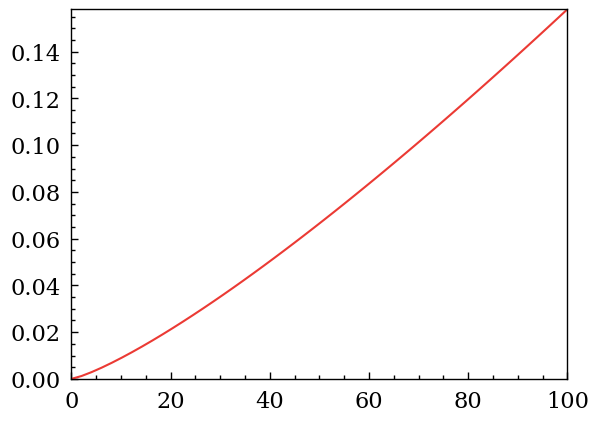

In [5]:
rs = np.linspace(0, 100)
h = rs**(5/4)*0.0005

plt.plot(rs, h)

In [2]:
import re

# Input file name
filename = "progress_tracking_files/progress_1000000.0_yr_2_gas_drag_on_10km.txt"

# Regex pattern to capture core number and time
pattern = r"Core\s+(\d+)\s+finished\s+and\s+took\s+([\d.]+)\s+min"

cores = []
times = []

with open(filename, "r") as file:
    for line in file:
        match = re.search(pattern, line)
        if match:
            core_id = int(match.group(1))
            time_min = float(match.group(2))
            
            cores.append(core_id)
            times.append(time_min)

# Output results
#print("Extracted data:")
#for c, t in zip(cores, times):
    #print(f"Core {c}: {t} min")

# Optional: compute average
if times:
    avg = sum(times) / len(times)
    print(f"\nAverage time: {avg:.3f} min")

print(avg*7620/(60*56))


Average time: 8.499 min
19.273820951095136


In [3]:
files = glob.glob('core_outputs_yr2/gas_drag/*6673001*.nc')

print(files)

['core_outputs_yr2/gas_drag/core_402_1000000.0_yr_ptcl_6673001_3_pl_single_particle_2_NOGD.nc', 'core_outputs_yr2/gas_drag/core_402_1000000.0_yr_ptcl_6673001_3_pl_single_particle_2.nc']


#  Clustering analysis

In [2]:
test_files = glob.glob(f'core_outputs_yr2/*10000.0*test.nc*')
gd_files = [f for i in np.arange(40, 49, 1)
            for f in glob.glob(f'core_outputs_yr2/gas_drag/*core_{i}_*2_pl*params_NOGD.nc')]
#gd_files = glob.glob(f'core_outputs_yr2/gas_drag/*core_*_2_pl*params.nc')
print(len(gd_files))


0


In [4]:

def get_ptcls(filenames):
    all_x = []
    all_y = []
    all_z = []
    all_inc = []
    all_a = []
    all_e = []
    all_x_pl = []
    all_y_pl = []
    all_zpl = []

    allepl = []
    allapl = []

    for file in filenames:
        with netCDF4.Dataset(file, 'r') as ncfile:
            #only open the last timestamp
            test_particles = ncfile['test_particles'][:]
            massive_bodies = ncfile['massive_bodies'][:]
            x, y, z = test_particles[:, :, 1], test_particles[:, :, 2], test_particles[:, :, 3]
            xpl, ypl, zpl = massive_bodies[:, :, 1], massive_bodies[:, :, 2], massive_bodies[:, :, 3] 
            ple, pla = massive_bodies[:, 1, 4], massive_bodies[:, 1, 5]  
            times = ncfile['test_particles'][:, :, 0] 

            a = test_particles[:, :, 5]
            ecc = test_particles[:,:,4]
           # ecc = np.ma.filled(ecc, np.nan)
            valid_mask = (a > 0) & (ecc < 1)
            inc =test_particles[:, :, 6]
            inc[~valid_mask] = np.nan
            #ecc[~valid_mask] = np.nan
            inc[valid_mask] = np.degrees(inc[valid_mask])
            #a[~valid_mask] = np.nan

            #add failed cores check!!

        all_x.append(x)
        all_y.append(y)
        all_z.append(z)
        all_inc.append(inc)
        all_a.append(a)
        all_e.append(ecc)
        all_x_pl.append(xpl)
        all_y_pl.append(ypl)
        all_zpl.append(zpl)
        allepl.append(ple)
        allapl.append(pla)
    
    pos_x = np.concatenate(all_x, axis=1)   # (nt, total_particles)
    pos_y = np.concatenate(all_y, axis=1)
    pos_z = np.concatenate(all_z, axis=1)
    final_inc = np.concatenate(all_inc, axis=1)
    final_e = np.concatenate(all_e, axis=1)
    final_a = np.concatenate(all_a, axis=1)
    final_pl_x = np.concatenate(all_x_pl, axis=1)
    final_pl_y = np.concatenate(all_y_pl, axis=1)
    final_pl_z = np.concatenate(all_zpl, axis=1)

    final_a_pl = np.concatenate(allapl, axis=0)
    final_e_pl = np.concatenate(allepl, axis=0)


    return pos_x, pos_y, pos_z, final_inc, final_e, final_a, final_pl_x, final_pl_y, final_pl_z, allapl, allepl, times


In [ ]:
particles = get_ptcls(gd_files)


In [ ]:

print(particles[-2])
print(len(particles[-2][0]))

In [ ]:
threeplfile = [f for i in np.arange(0, 49, 1)
            for f in glob.glob(f'core_outputs_yr2/gas_drag/*core_{i}_*3_pl*params.nc')]

threeplfile = glob.glob(f'core_outputs_yr2/gas_drag/*core_23_*_*3_pl*.nc')
threeplptcls = get_ptcls(threeplfile)

print(np.shape(threeplptcls[-2]))
    #print(np.shape(particles[i]))

In [ ]:
for i in range(3):
    threeplfile = glob.glob(f'core_outputs_yr2/gas_drag/*core_{i}_*_*2_pl*.nc')
    particles = get_ptcls(threeplfile)
    times = (particles[-1][:,0])
    times_pl = np.arange(0, particles[6].shape[0]*10, 10)

    print(times_pl)

    eccentricity = particles[4]
    semimajor_axis = particles[5]
    inclination = particles[3]
    perihelion = semimajor_axis * (1 - eccentricity)
    pl_pos = np.sqrt(particles[6]**2 + particles[7]**2 + particles[8]**2)
    #plt.plot(times, perihelion)
    plt.plot(times_pl, pl_pos[:,1:])
    plt.text(13000, 10, 'Planet d')
    plt.text(13000, 22, 'Planet b')
    plt.text(13000, 35, 'Planet c')

    plt.xlabel('Time (years)')
    plt.ylabel('Distance (AU)')
    plt.title(f'Core {i}')
    plt.legend()
    plt.show()


In [ ]:
particles = get_ptcls(gd_files)


In [ ]:
times = (particles[-1][:,0])
eccentricity = particles[4]
semimajor_axis = particles[5]
inclination = particles[3]
position = np.sqrt(particles[0]**2 + particles[1]**2 + particles[2]**2)
perihelion = semimajor_axis * (1 - eccentricity)
print(position.shape)

print(len(particles[-2][6]))

In [ ]:
np.arange(0, 99, 11)

In [ ]:
for i in range(97200, 97350):
    #print(np.max(eccentricity[:,i])) # 9.96920997e+36
    print('t:', i*10)                       
    print('XY position:', position[i, 68])
    print('semimajor_axis:', semimajor_axis[i,68])
    print('eccentricity:', eccentricity[i,68])
    print('perihelion:', perihelion[i,68])
    print('a_pl:', particles[-3][6][i])
    print('e_pl:', particles[-2][6][i])


print(len(perihelion))

In [ ]:
def plotting_parameters(param, label, unit=None):

    plt.figure(figsize=(8, 5))
               
    #for i in range(eccentricity.shape[1]):
    plt.plot(times[:], param[:, 10:20], alpha=1, )
    #plt.plot(times[96000:97500],  particles[-3][6][96000:97500], alpha=1, label='planet')
    plt.yscale('log')

    print(np.shape(param))

    
    plt.xlabel("Time")
    plt.ylabel(f'{label} [{unit}]' if unit else f'{label}')
    plt.ylim(0, 40)
    #plt.legend()
    #plt.title("Eccentricity evolution of particles")
    plt.show()

plotting_parameters(semimajor_axis, 'Semimajos axis', 'AU')

# 3D animation (particle cluster and planets)

In [ ]:
import cmasher as cmr
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

def animate_particles(filenames, savefile):

    pos_x, pos_y, pos_z, all_inc, final_e, final_a, final_pl_x, final_pl_y, final_pl_z, times = get_ptcls(filenames)

    nt, _ = final_pl_x.shape
    print(nt)

    steps = 5
    tmax = nt
    tstart = 500
    print(np.max(all_inc[tstart:tmax]))

    frames_to_use = range(0, tmax, steps)

    fig = plt.figure(figsize=(8,7))
    ax = fig.add_subplot(111, projection="3d")
    
    #ax.set_aspect("equal")

    ax.set_xlim(-40, 40)
    ax.set_ylim(-40, 40)
    ax.set_zlim(-10, 10)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    ax.tick_params(axis='both', which='both', direction='in')
    ax.tick_params(axis='z', which='both', direction='in')

    cmap = cmr.cosmic
    norm = colors.Normalize(vmin=np.nanmin(all_inc[:tmax]), vmax=np.nanmax(all_inc[:tmax]))

    scat = ax.scatter([], [], [], marker='o', s=10,)
    scatt2 = ax.scatter([], [], [], marker='o', s=50)
    #ax.scatter(xs=0, ys=0, zs=0, s=100, c="orange", marker='*')

    # cbar = fig.colorbar(
    #     scat,
    #     ax=ax,
    #     fraction=0.035,   # width
    #     shrink=0.85,      # height
    #     pad=0.08          # spacing from axes
    # )    

    # cbar.ax.set_position([
    # cbar.ax.get_position().x0 + 0.08,
    # cbar.ax.get_position().y0,
    # cbar.ax.get_position().width,
    # cbar.ax.get_position().height
    # ])
    # cbar.set_label("Inclination [deg]", rotation=270, labelpad=25)
    # ax.tick_params(width=0.8, length=4)
    # cbar.ax.tick_params(width=0.8, length=3, direction='in')
    
    scat.set_depthshade(False)
    scatt2.set_depthshade(False)

    def update(frame):
        inc = all_inc[frame]
        frame_colours = cmap(norm(inc))    

        x = pos_x[frame, :]
        y = pos_y[frame, :]
        z = pos_z[frame, :]   

        scat._offsets3d = (x, y, z)
        scat.set_color(frame_colours)

        x_pl = final_pl_x[frame, 1:]
        y_pl = final_pl_y[frame, 1:]
        z_pl = final_pl_z[frame, 1:]
        scatt2._offsets3d = (x_pl, y_pl, z_pl)
        scatt2.set_color(['magenta', 'red', 'cyan'])

        ax.set_title(f"t = {frame}/{tmax} yr", y=0.99)

        return scat, scatt2
    

    plt.tight_layout()

    ani = FuncAnimation(fig, update, frames=frames_to_use, interval=15, blit=True)

    writer = 'pillow' if savefile.endswith('.gif') else 'ffmpeg'
    ani.save(savefile, fps=10, dpi=200, writer=writer)
    

    return ani

animate_particles([threeplfile], "animations/animation_3pl_wacko.mp4")

# 2D animation of particles and planets

In [ ]:
import cmasher as cmr
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

def animate_particles(filenames, savefile):

    pos_x, pos_y, _, all_inc, final_e, final_a, final_pl_x, final_pl_y, _, times = get_ptcls(filenames)

    nt, _ = final_pl_x.shape
    print(nt)

    steps = 1
    tmax = nt
    tstart = tmax - 100
    print(np.max(all_inc[tstart:tmax]))

    frames_to_use = range(tstart, tmax, steps)

    fig = plt.figure(figsize=(8,7))
    ax = fig.add_subplot(111)
    
    #ax.set_aspect("equal")

    ax.set_xlim(-40, 40)
    ax.set_ylim(-40, 40)

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.tick_params(axis='both', which='both', direction='in')

    cmap = cmr.cosmic
    norm = colors.Normalize(vmin=np.nanmin(all_inc[:tmax]), vmax=np.nanmax(all_inc[:tmax]))

    scat = ax.scatter([], [],  marker='o', s=10,)
    scatt2 = ax.scatter([], [],  marker='o', s=50)

    def update(frame):
        inc = all_inc[frame]
        frame_colours = cmap(norm(inc))    

        x = pos_x[frame, :]
        y = pos_y[frame, :]

        #scat.set_offsets(np.c_[x, y])

        #scat.set_color(frame_colours)

        x_pl = final_pl_x[frame, :]
        y_pl = final_pl_y[frame, :]

        scatt2.set_offsets(np.c_[x_pl, y_pl])
        scatt2.set_color(['orange','cyan', 'red', 'magenta'])

        ax.set_title(f"t = {frame*10}/{tmax*10} yr", y=0.99)

        return scat, scatt2
    

    plt.tight_layout()

    ani = FuncAnimation(fig, update, frames=frames_to_use, interval=15, blit=True)

    writer = 'pillow' if savefile.endswith('.gif') else 'ffmpeg'
    ani.save(savefile, fps=10, dpi=200, writer=writer)
    

    return ani

newfile = "core_outputs_yr2/gas_drag/core_28_1000000.0_yr_ptcl_3222005_3_pl_w_planet_params.nc"
animate_particles([newfile], "animations/animation_3pl_wacko_2.mp4")

# No clustering analysis

In [6]:
files_with_gas = (glob.glob(f'core_outputs_yr2/gas_drag_final/*10km*'))
files_no_gas = glob.glob(f'core_outputs_yr2/gas_drag_final/*100km*')
files1km =  glob.glob(f'core_outputs_yr2/gas_drag_final/*1km*')
files_w_gas_3_pl = glob.glob(f'core_outputs_yr2/gas_drag/*3_pl_single_particle_2.nc')
files_no_gas_3_pl = glob.glob(f'core_outputs_yr2/gas_drag/*3_pl_single_particle_2_NOGD.nc')

print(len(files_with_gas), len(files_no_gas), len(files_w_gas_3_pl), len(files_no_gas_3_pl))

def get_core_number(filename):
    base = os.path.basename(filename)
    m = re.search(r'core_(\d+)_', base)
    return int(m.group(1)) if m else -1

sorted_gas_1km_2pl = sorted(files1km, key=get_core_number)
sorted_gas_10km_2pl = sorted(files_with_gas, key=get_core_number)
sorted_gas_100km_2pl = sorted(files_no_gas, key=get_core_number)
sorted_three_pl_gas = sorted(files_w_gas_3_pl, key=get_core_number)
sorted_no_gas_3_pl = sorted(files_no_gas_3_pl, key=get_core_number)


7638 7638 1180 1180


## extract files that failed

In [7]:

from netCDF4 import Dataset
from tqdm import tqdm
import numpy as np


def filter_valid_netcdf_files(filenames):

    good_files = []

    for f in tqdm(filenames, desc="Checking files"):
        try:
            with Dataset(f, "r") as ds:

                # Check if there's at least one non-empty variable
                has_data = False
                for var in ds.variables.values():
                    if var.size > 0:
                        has_data = True
                        break

                if has_data:
                    good_files.append(f)

        except Exception:
            continue

    return good_files

valid_2_pl_10km = filter_valid_netcdf_files(sorted_gas_10km_2pl)
valid_2_pl_100km = filter_valid_netcdf_files(sorted_gas_100km_2pl)

Checking files: 100%|██████████| 7638/7638 [00:54<00:00, 139.75it/s]


In [8]:
valid_2_pl_1km = filter_valid_netcdf_files(sorted_gas_1km_2pl)

Checking files: 100%|██████████| 7638/7638 [00:56<00:00, 135.54it/s]


In [4]:
print(len(valid_2_pl_100km))

7629


In [7]:
def get_min_peri(filename):

    min_peri_list = []
    final_time = []
    ecc_list = []
    filecount = 0

    with netCDF4.Dataset(filename, 'r') as ncfile:

        test_particles = ncfile['test_particles'][:]
        massive_bodies = ncfile['massive_bodies'][:]
        tf = massive_bodies[-1][0][0]/5
        ple, pla = massive_bodies[:, :, 4], massive_bodies[:, :, 5] 
        
        apo_dist_b = pla[:,1] * (1 + ple[:,1]) 
        peri_dist_c = pla[:,2] * (1 - ple[:,2]) 
        c1 = np.all(ple < 1)
        c2 = np.all(apo_dist_b < 0.99*peri_dist_c)
        
        if c1 and c2:
            filecount += 1

            a = test_particles[:, 5]
            ecc = test_particles[:,4]
            min_peri = np.min(a * (1 - ecc))

            min_peri_list.append(min_peri)
            ecc_list.append(ecc)
            final_time.append(tf)

    return min_peri_list, ecc_list, final_time, filecount 

from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import os

# --- helper to split into chunks ---
def chunked(lst, chunk_size):
    for i in range(0, len(lst), chunk_size):
        yield lst[i:i + chunk_size]


# --- process a batch of files in one worker ---
def process_batch(files):
    results = []
    for f in files:
        try:
            results.append(get_min_peri(f))
        except Exception as e:
            print(f"Error in {f}: {e}")
    return results


def combine_all_particles(filenames, chunk_size=20, max_workers=20):

    if max_workers is None:
        max_workers = min(16, os.cpu_count())  # cap to avoid I/O overload

    min_peri_list = []
    final_times = []
    ecc_list = []
    filecount_total = 0

    batches = list(chunked(filenames, chunk_size))

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        try:
            futures = [executor.submit(process_batch, batch) for batch in batches]

            for future in tqdm(as_completed(futures), total=len(futures), desc="processing"):
                try:
                    batch_results = future.result(timeout=30)  # seconds per batch
                except Exception as e:
                    print(f"Batch failed or timed out: {e}")
                    continue

                for min_peri, ecc, tfinal, filecount in batch_results:
                    min_peri_list.append(min_peri)
                    final_times.append(tfinal)
                    ecc_list.append(ecc)
                    filecount_total += filecount

        except KeyboardInterrupt:
            executor.shutdown(wait=False, cancel_futures=True)
            raise

    return min_peri_list, ecc_list, final_times, filecount_total

In [8]:
import netCDF4
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

def get_min_peri(filename):
    try:
        with netCDF4.Dataset(filename, 'r') as ncfile:
            mb = ncfile['massive_bodies']

            # ✅ Read only the last timestep for tf, and only columns 4&5
            # instead of loading the full [T, N, vars] array
            last       = mb.shape[0] - 1
            tf         = mb[last, 0, 0] / 5

            ple        = mb[:, :, 4]          # still needs full time axis for c1/c2
            pla        = mb[:, :, 5]

            apo_dist_b  = pla[:, 1] * (1 + ple[:, 1])
            peri_dist_c = pla[:, 2] * (1 - ple[:, 2])

            if not (np.all(ple < 1) and np.all(apo_dist_b < 0.99 * peri_dist_c)):
                return None                   # fast-reject before touching test_particles

            tp  = ncfile['test_particles']
            # ✅ Read only the two columns you need, not the full particle array
            a   = tp[:, 5]
            ecc = tp[:, 4]

            return np.min(a * (1 - ecc)), ecc, tf

    except Exception:
        return None


def combine_all_particles(filenames, max_workers=20):
    min_peri_list  = []
    ecc_list       = []
    final_times    = []
    filecount      = 0

    # ✅ executor.map + chunksize beats manual batching + as_completed for uniform tasks
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        for result in tqdm(
            executor.map(get_min_peri, filenames, chunksize=20),
            total=len(filenames),
            desc="processing"
        ):
            if result is None:
                continue
            min_peri, ecc, tf = result
            min_peri_list.append(min_peri)
            ecc_list.append(ecc)
            final_times.append(tf)
            filecount += 1

    return min_peri_list, ecc_list, final_times, filecount

In [9]:
all_particles_gas_100km = combine_all_particles(valid_2_pl_100km)
all_particles_gas_10km = combine_all_particles(valid_2_pl_10km)
all_particles_gas_1km = combine_all_particles(valid_2_pl_1km)

processing: 100%|██████████| 7626/7626 [28:05<00:00,  4.53it/s] 


In [ ]:
all_particles_gas_1km = combine_all_particles(valid_2_pl_1km)

processing:   0%|          | 0/7626 [00:35<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
three_pl_gas_1 = combine_all_particles(sorted_three_pl_gas[:])
three_pl_no_gas = combine_all_particles(sorted_no_gas_3_pl[:])

processing: 100%|██████████| 1179/1179 [00:30<00:00, 38.82it/s]


## Inclinations

In [2]:
# files_with_gas_2_pl = valid_2_pl_100km #(glob.glob(f'core_outputs_yr2/gas_drag_final/*2_pl*single_particle_2.nc'))
# files_no_gas_2_pl = glob.glob(f'core_outputs_yr2/gas_drag/*2_pl*single_particle_2_NOGD.nc')

# files_w_gas_3_pl = glob.glob(f'core_outputs_yr2/gas_drag/*3_pl_single_particle_2.nc')
# files_no_gas_3_pl = glob.glob(f'core_outputs_yr2/gas_drag/*3_pl_single_particle_2_NOGD.nc')

def get_stargrazers(filename, n_planets):
    global n_particles

    params = ['ecc', 'semimajor', 'inc', 'hash']
    
    star_grazed = {param: [] for param in params}
    
    N = len(filename)
    print(f'Initially: {N} files')

    filecount = 0

    for index, file in enumerate(filename):
            #planets_all = ncfile['massive_bodies'][-1, 1:, :]
        try:
            with netCDF4.Dataset(file, 'r') as ncfile:

                if 'massive_bodies' not in ncfile.variables:
                    continue

                mb = ncfile['massive_bodies']

                # shape safety check
                if mb.shape[0] == 0:
                    continue

                # last timestep safely
                last = mb.shape[0] - 1

                massive_bodies_a = mb[last, 0:n_planets, 5]
                massive_bodies_e = mb[last, 0:n_planets, 4]


            dist = massive_bodies_a * (1+massive_bodies_e)
            dist_small = massive_bodies_a * ( 1 - massive_bodies_e)

            c1 = np.all(massive_bodies_e < 1)

            c2 = np.all(dist <= 87)

            if n_planets == 2:
                c3 = ((dist[0] < dist_small[1]))
                #d_pos = np.sqrt(planets_all[-1, 1]**2 + planets_all[-1, 2]**2)
            
            # if n_planets == 3:
            #     c3 = ((dist[2] < dist_small[0])) and (dist[0] < dist_small[1]) 
            #     #d_pos = np.sqrt(planets_all[-1, 0]**2 + planets_all[-1, 1]**2)

            if n_planets == 3:
                c3 = ((dist[0] < dist_small[1])) and (dist[1] < dist_small[2] ) 
            
            if c1 and c3 and c2:  
                filecount += 1
                #print(planets_all[:,3:5])

                if 'star_grazed' in ncfile.variables:
                    grazed_particle = ncfile['star_grazed'][:]
                    if np.any(grazed_particle):
                        print('found one')
                        if np.sqrt(grazed_particle[:,1]**2 + grazed_particle[:,2]**2 + grazed_particle[:,3]**2) < 8:
                            star_grazed['inc'].extend(np.degrees(grazed_particle[:,6]).compressed())
                            star_grazed['semimajor'].extend(grazed_particle[:,5].compressed())
                            star_grazed['ecc'].extend(grazed_particle[:,4].compressed())
                            star_grazed['hash'].extend(grazed_particle[:,-1].compressed())
        
        except Exception as e:
            # 🔴 skip bad files safely
            print(f"Skipping file {file}: {e}")
            continue

    print(f'Finally: {filecount} files')
    print(f'Number of stargrazers: {len(star_grazed["inc"])}')
    return star_grazed #{'migrated': migrated_array, 'ejected': ejected_array}

In [3]:
import numpy as np
import netCDF4

def get_stargrazers(filename, n_planets):

    star_grazed = {'ecc': [], 'semimajor': [], 'inc': [], 'hash': []}

    filecount = 0
    print(f"Initially: {len(filename)} files")

    for file in filename:

        try:
            # --- HARD SAFE OPEN ---
            with netCDF4.Dataset(file, 'r') as ncfile:

                # check variable exists
                if 'massive_bodies' not in ncfile.variables:
                    continue

                mb = ncfile['massive_bodies']

                # shape safety check
                if mb.shape[0] == 0:
                    continue

                # last timestep safely
                last = mb.shape[0] - 1

                massive_bodies_a = mb[last, 0:n_planets, 5]
                massive_bodies_e = mb[last, 0:n_planets, 4]

                if massive_bodies_a.size == 0 or massive_bodies_e.size == 0:
                    continue

                dist = massive_bodies_a * (1 + massive_bodies_e)
                dist_small = massive_bodies_a * (1 - massive_bodies_e)

                c1 = np.all(massive_bodies_e < 1)
                c2 = np.all(dist <= 87)

                if n_planets == 2:
                    c3 = (dist[0] < dist_small[1])
                elif n_planets == 3:
                    c3 = (dist[0] < dist_small[1]) and (dist[1] < dist_small[2])
                else:
                    continue

                if not (c1 and c2 and c3):
                    continue

                # only count AFTER full validation
                filecount += 1

                if 'star_grazed' not in ncfile.variables:
                    continue

                grazed_particle = ncfile['star_grazed'][:]

                if grazed_particle.size == 0:
                    continue

                r = np.sqrt(
                    grazed_particle[:, 1]**2 +
                    grazed_particle[:, 2]**2 +
                    grazed_particle[:, 3]**2
                )

                valid = r < 8

                if np.any(valid):

                    star_grazed['inc'].extend(np.degrees(grazed_particle[valid, 6]).tolist())
                    star_grazed['semimajor'].extend(grazed_particle[valid, 5].tolist())
                    star_grazed['ecc'].extend(grazed_particle[valid, 4].tolist())
                    star_grazed['hash'].extend(grazed_particle[valid, -1].tolist())
        except Exception as e:
            print(f"Skipping file {file}: {e}")
            continue

    print(f"Finally: {filecount} valid files")
    print(f"Number of stargrazers: {len(star_grazed['inc'])}")

    return star_grazed

### for 2 and 3 planet in 1 plot

In [12]:

def get_inclinations_and_plot(files_2_pl, files_3_pl, gas_on=False):
    results_3_pl = get_stargrazers(files_3_pl, 3)
    results_2_pl = get_stargrazers(files_2_pl, 2)

    incs_mig_all_2_pl = results_2_pl['inc']
    a_mig_all_2_pl = results_2_pl['semimajor']

    incs_mig_all_3_pl = results_3_pl['inc']
    a_mig_all_3_pl = results_3_pl['semimajor']

    fig, ax = plt.subplots(1,2, figsize=(14,6))

    #new:
    color_blue = [
        "#73c3ee",  # medium
        "#193F77",  # dark
    ]

    color_pink = [ "#CAA1CD", "#841550FF"]

    mytriad = [
        "#b594ec",  # very light lavender (great on dark magenta)
        "#c384d1",  # soft mid-tone (works on both backgrounds)
        "#DD629C"   # vivid pink (pops on grey, still visible on your bg)
    ]

    my_blues = ["#A8CBFF", "#7ed5eb"]

    for i, inc in enumerate(incs_mig_all_2_pl):
        ax[0].plot(a_mig_all_2_pl[i], inc, marker='o', color=color_blue[1], markersize=5,  alpha=0.7)

    for i, inc in enumerate(incs_mig_all_3_pl):
        ax[1].plot(a_mig_all_3_pl[i], inc, marker='o', color=color_pink[1], markersize=5,  alpha=0.7)

    ax[0].plot(21, 2.3, 'o', markersize=12, color=my_blues[1], label='PDS 70 b')
    ax[0].plot(34, 1.5, 'o', markersize=12, color=my_blues[0], label='PDS 70 c')

    ax[1].plot(11, 23, 'o', alpha=1, markersize=12, color=mytriad[2], label='PDS 70 d')
    ax[1].plot(21, 0.2, 'o', alpha=1, markersize=12, color=mytriad[0], label='PDS 70 b')
    ax[1].plot(34, 0.4, 'o', alpha=1, markersize=12, color=mytriad[1], label='PDS 70 c')

    ax[1].text(41, 38.3,
            'disc inc. w.r.t. \n line of sight',
            va='center', fontsize=12, color="k", ha='left')

    for i in range(2):

        ax[i].set_xlim(0, 40)
        ax[i].axvspan(0, 18, color='grey', alpha=0.15)
        ax[i].axvspan(54, 87, color='grey', alpha=0.15)
        ax[i].axhline(38.3, color='k', linestyle='dashed', linewidth=1)

        ax[i].grid(alpha=0.3)
        ax[i].set_ylim(-5, 180)
        ax[i].legend()

    # Labels & title
    ax[0].set_xlabel('Semimajor axis (AU)')
    ax[0].set_ylabel('Inclination (deg)')
    ax[0].set_title('Two-planet case')
    ax[1].set_xlabel('Semimajor axis (AU)')
    ax[1].set_title('Three-planet case')

    # if gas_on:
    #     plt.suptitle('Inclinations of star-grazed particles at the time of star-grazing (with gas drag)')
    # else:
    #     plt.suptitle('Inclinations of star-grazed particles at the time of star-grazing (no gas drag)')

    plt.tight_layout()

    # plt.savefig(f'plots/inclinations_stargrazed_combined_{"with_gas" if gas_on else "no_gas"}.png')
    # plt.savefig(f'plots/inclinations_stargrazed_combined_{"with_gas" if gas_on else "no_gas"}.pdf')
    plt.show()

get_inclinations_and_plot(valid_2_pl_100km, valid_2_pl_10km)
#get_inclinations_and_plot(files_no_gas_2_pl, files_no_gas_3_pl, gas_on=False)

Initially: 7638 files


KeyboardInterrupt: 

In [10]:
results_1km = get_stargrazers(valid_2_pl_1km, 2)
results_10km = get_stargrazers(valid_2_pl_10km, 2)
results_100km = get_stargrazers(valid_2_pl_100km, 2)

Initially: 7638 files
Finally: 7638 valid files
Number of stargrazers: 636
Initially: 7638 files
Finally: 7638 valid files
Number of stargrazers: 710
Initially: 7629 files
Finally: 7628 valid files
Number of stargrazers: 721


### 1 plot per planet with 1, 10, and 100 km cases 

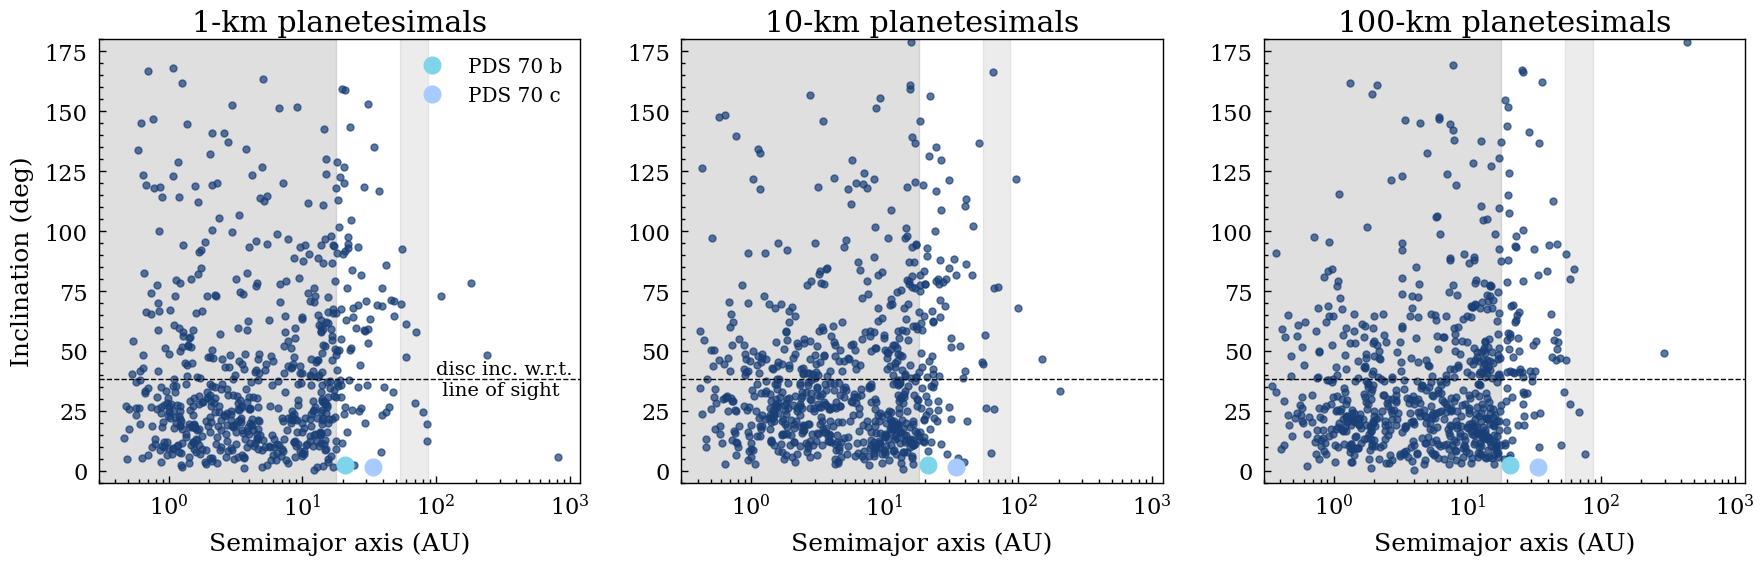

In [19]:

def get_inclinations_and_plot(size_1, size_10, size_100, n_pl):

    incs_mig_all_1km = results_1km['inc']
    a_mig_all_1km = np.array(results_1km['semimajor'])
    e_mig_all_1km = np.array(results_1km['ecc'])
    peri_1km = a_mig_all_1km * (1 - e_mig_all_1km)

    incs_mig_all_10km = results_10km['inc']
    a_mig_all_10km = np.array(results_10km['semimajor'])
    e_mig_all_10km = np.array(results_10km['ecc'])
    peri_10km = a_mig_all_10km * (1 - e_mig_all_10km)

    incs_mig_all_100km = results_100km['inc']
    a_mig_all_100km = np.array(results_100km['semimajor'])
    e_mig_all_100km = np.array(results_100km['ecc'])
    peri_100km = a_mig_all_100km * (1 - e_mig_all_100km)

    fig, ax = plt.subplots(1,3, figsize=(18, 6))

    #new:
    if n_pl == 2:
        c = [
            "#73c3ee",  # medium
            "#193F77",  # dark
        ]

        pl_colors = ["#A8CBFF", "#7ed5eb"]

    
    else:
        pl_colors = [
        "#b594ec",  # very light lavender (great on dark magenta)
        "#c384d1",  # soft mid-tone (works on both backgrounds)
        "#DD629C"   # vivid pink (pops on grey, still visible on your bg)
    ]

        c = [ "#CAA1CD", "#841550FF"]


    for i, inc in enumerate(incs_mig_all_1km):
        ax[0].plot(a_mig_all_1km[i], inc, marker='o', color=c[1], markersize=5,  alpha=0.7)

    for i, inc in enumerate(incs_mig_all_10km):
        ax[1].plot(a_mig_all_10km[i], inc, marker='o', color=c[1], markersize=5,  alpha=0.7)

    for i, inc in enumerate(incs_mig_all_100km):
        ax[2].plot(a_mig_all_100km[i], inc, marker='o', color=c[1], markersize=5,  alpha=0.7)

    ax[0].text(100, 38.1,
            'disc inc. w.r.t. \n line of sight',
            va='center', fontsize=14, color="k", ha='left')

    for i in range(3):
        ax[i].plot(21, 2.3, 'o', markersize=12, color=pl_colors[1], label='PDS 70 b')
        ax[i].plot(34, 1.5, 'o', markersize=12, color=pl_colors[0], label='PDS 70 c')
        if n_pl == 3:
                ax[1].plot(11, 23, 'o', alpha=1, markersize=12, color=pl_colors[2], label='PDS 70 d')

        #ax[i].set_xlim(0, 100)
        ax[i].axvspan(0, 18, color='grey', alpha=0.25)
        ax[i].axvspan(54, 87, color='grey', alpha=0.15)
        ax[i].axhline(38.3, color='k', linestyle='dashed', linewidth=1)
        ax[i].set_xscale('log')
        #ax[i].grid(alpha=0.3)
        ax[i].set_ylim(-5, 180)
        ax[i].set_xlim(0.3, 1200)
    
    ax[0].legend()

    # Labels & title
    ax[0].set_xlabel('Semimajor axis (AU)')
    ax[0].set_ylabel('Inclination (deg)')
    ax[0].set_title('1-km planetesimals')
    ax[1].set_xlabel('Semimajor axis (AU)')
    ax[1].set_title('10-km planetesimals')
    ax[2].set_xlabel('Semimajor axis (AU)')
    ax[2].set_title('100-km planetesimals')

    # if gas_on:
    #     plt.suptitle('Inclinations of star-grazed particles at the time of star-grazing (with gas drag)')
    # else:
    #     plt.suptitle('Inclinations of star-grazed particles at the time of star-grazing (no gas drag)')

    plt.tight_layout()

    plt.savefig(f'plots/inclinations_stargrazed_{n_pl}_planets_all_pl_sizes.pdf', bbox_inches='tight')
    #plt.savefig(f'plots/inclinations_stargrazed_combined_{"with_gas" if gas_on else "no_gas"}.pdf')
    plt.show()

get_inclinations_and_plot(valid_2_pl_1km, valid_2_pl_10km, valid_2_pl_100km, 2)
#get_inclinations_and_plot(files_no_gas_2_pl, files_no_gas_3_pl, gas_on=False)

## Uneven binning

file count: 1947 and 1943
[ 0.    0.05  0.1   0.2   0.5   1.    5.   10.  ]
[131  51  50  78  87 677 552]


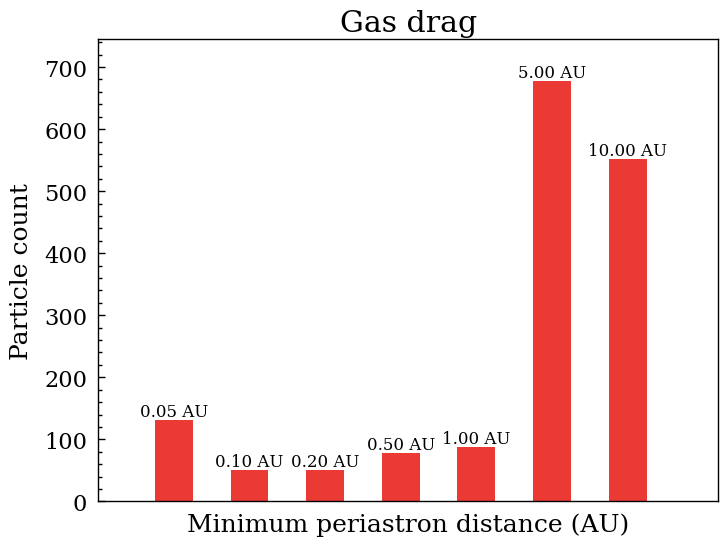

In [15]:
bins = [0, 0.05, 0.1, 0.2, 0.5, 1, 5, 10]
print('file count:', all_particles_gas[-1], 'and', all_particles_no_gas[-1])

counts, bin_edges = np.histogram(all_particles_gas[0], bins=bins, density=False)
print(bin_edges)
x = np.arange(len(counts))  # equally spaced positions

fig = plt.figure(figsize=(8, 6))
plt.bar(x, counts, width=0.5,)

plt.xlabel('Minimum periastron distance (AU)')
plt.ylabel('Particle count')
plt.ylim(0, 1.1*np.max(counts))
plt.xlim(-1, len(counts)+0.2)
for i in range(0, len(counts)):
    plt.text(x[i], counts[i], f'{bins[i+1]:.2f} AU', ha='center', fontsize=12, va='bottom')
print(counts)
plt.title('Gas drag')
plt.xticks([])

plt.show()

## Regular binning

In [1]:
def filter_data(filename):

    periastrons = np.array([peri for peri in filename[0] if peri])
    eccentricities = np.array([i for i in filename[1] if len(i) > 0])

    ejected_peris = []
    non_ej_peris = []
    for i, (peri, ecc) in enumerate(zip(periastrons, eccentricities)):
    
        masked_ecc = np.ma.filled(ecc[0], np.nan)

        invalid_indices = np.where((masked_ecc > 1))[0]

        if len(invalid_indices) > 0:
            first_nan = invalid_indices[0]

            # Only use values BEFORE ejection
            peri_before = peri[:first_nan]

            if len(peri_before) > 0:
                ejected_peris.append(np.min(peri_before))

        else:
            # Never ejected → use all values
            non_ej_peris.append(np.min(peri))

    return ejected_peris, non_ej_peris

In [16]:

ejected_peris, non_ej_peris = filter_data(all_particles_gas)
ejected_peris_no_gas, non_ej_peris_no_gas = filter_data(all_particles_no_gas)
ej_peri_three_pl, non_ej_peri_three_pl = filter_data(three_pl_gas_1)
ej_peri_three_pl_no_gas, non_ej_peri_three_pl_no_gas = filter_data(three_pl_no_gas)

In [17]:
print(len(ej_peri_three_pl) + len(non_ej_peri_three_pl))
print(len(ej_peri_three_pl_no_gas) + len(non_ej_peri_three_pl_no_gas))

1170
1167


In [18]:
print(len(ejected_peris) + len(non_ej_peris))

1947


[ 0.  2.  4.  6.  8. 10. 12. 14. 16. 18.]
[190 106 119 112  92  71  59  42  37]
21


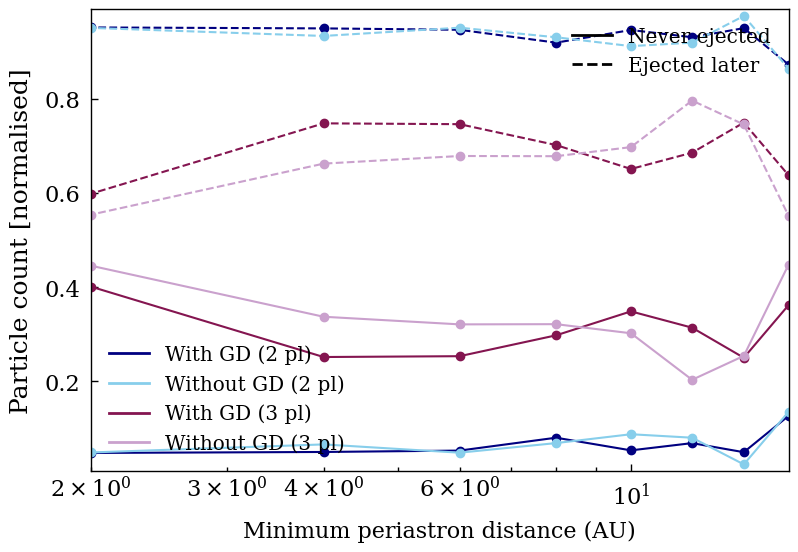

In [28]:
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

#
bins_2 = np.arange(0, 18.5, 2)
print(bins_2)
#bins_2 = [0.15, 0.2, 0.5, 1, 5, 10, 18]

fig, ax = plt.subplots(figsize=(9, 6))
counts, bin_edges = np.histogram(non_ej_peris, bins=bins_2, density=False)
counts2, bin_edges2 = np.histogram(non_ej_peris_no_gas, bins=bins_2, density=False)

counts3, _ = np.histogram(ejected_peris, bins=bins_2, density=False)
counts4, _ = np.histogram(ejected_peris_no_gas, bins=bins_2, density=False)

counts5, _ = np.histogram(ej_peri_three_pl, bins=bins_2, density=False)
print(counts5)
counts6, _ = np.histogram(non_ej_peri_three_pl, bins=bins_2, density=False)


counts7, _ = np.histogram(ej_peri_three_pl_no_gas, bins=bins_2, density=False)
counts8, _ = np.histogram(non_ej_peri_three_pl_no_gas, bins=bins_2, density=False)

w = 0.5

color_pink1 = "#841550FF" # darker purple
color_pink2 = "#CAA1CD" # "#CAA1CD"

color1 = 'navy'  # dark
color2 = 'skyblue'  # medium


plt.plot(bins_2[:-1], counts/(counts+counts3), 'o-', color=color1, alpha=1, )

plt.plot(bins_2[:-1], counts3/(counts3+counts), 'o--', color=color1, alpha=1, )

plt.plot(bins_2[:-1], counts2/(counts2+counts4),  'o-', color=color2,  alpha=1,  )

plt.plot(bins_2[:-1], counts4/(counts4+counts2),  'o--', color=color2,  alpha=1, )

plt.plot(bins_2[:-1], counts5/(counts5+counts6),  'o--', color=color_pink1,  alpha=1)

plt.plot(bins_2[:-1], counts6/(counts5+counts6),  'o-', color=color_pink1,  alpha=1)

plt.plot(bins_2[:-1], counts7/(counts7+counts8),  'o--', color=color_pink2,  alpha=1)

plt.plot(bins_2[:-1], counts8/(counts7+counts8),  'o-', color=color_pink2,  alpha=1)


print(np.sum(counts[0:2]))
ax.set_xlabel('Time [Myr]', fontsize=16)
#ax.tick_params(axis='y', labelright=False, right=True)
#ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

color_legend = [
    Line2D([0],[0], color=color1, lw=2, label='With GD (2 pl)'),
    Line2D([0],[0], color=color2, lw=2, label='Without GD (2 pl)'),
    Line2D([0],[0], color=color_pink1, lw=2, label='With GD (3 pl)'),
    Line2D([0],[0], color=color_pink2, lw=2, label='Without GD (3 pl)')
]

legend1 = plt.legend(handles=color_legend, loc='lower left')
plt.gca().add_artist(legend1)

style_legend = [
    Line2D([0],[0], color='black', lw=2, linestyle='-', label='Never ejected'),
    Line2D([0],[0], color='black', lw=2, linestyle='--', label='Ejected later')
]

plt.legend(handles=style_legend, loc='upper right')

ax.set_xticks(np.arange(0, 18, 2))

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: str(int(x)) if x.is_integer() else "")
)

ax.minorticks_off()
#plt.xticks(edges)
plt.xlabel('Minimum periastron distance (AU)')
plt.ylabel('Particle count [normalised]')
#plt.xlim(-0.5, 17)#
#plt.ylim(0.05, 0.6)

#plt.yscale('log')
plt.xscale('log')
# plt.legend(loc='center left',        # align vertically centered to axes
#         bbox_to_anchor=(1.02, 0.5),  # x=1.02 → just outside, y=0.5 → center vertically
#         borderaxespad=0,          # padding between axes and legend
#         frameon=False,
#         fontsize=16  )
# for i in range(0, len(counts)):
#     plt.text(x[i], counts[i], f'{bins[i+1]:.2f} AU', ha='center', fontsize=12, va='bottom')

#plt.title('Minimum periastron of particles, considering ejected particles or not (2 planets)', fontsize=14)
plt.show()

In [50]:
print(all_particles_gas[1])


[[masked_array(data=[0.43671372532844543, 0.1640656590461731,
                   0.43110209703445435, ..., --, --, --],
             mask=[False, False, False, ...,  True,  True,  True],
       fill_value=9.96921e+36,
            dtype=float32)], [masked_array(data=[0.5040121674537659, 0.29619547724723816,
                   0.10782162845134735, ..., --, --, --],
             mask=[False, False, False, ...,  True,  True,  True],
       fill_value=9.96921e+36,
            dtype=float32)], [masked_array(data=[0.3579115867614746, 0.412949800491333,
                   0.31408795714378357, ..., --, --, --],
             mask=[False, False, False, ...,  True,  True,  True],
       fill_value=9.96921e+36,
            dtype=float32)], [masked_array(data=[0.35095295310020447, 0.30924129486083984,
                   0.18666628003120422, ..., 0.9957990646362305,
                   0.9957990646362305, 0.9957990646362305],
             mask=[False, False, False, ..., False, False, False],
       fi

In [51]:
print(all_particles_gas[1][1])


[masked_array(data=[0.5040121674537659, 0.29619547724723816,
                   0.10782162845134735, ..., --, --, --],
             mask=[False, False, False, ...,  True,  True,  True],
       fill_value=9.96921e+36,
            dtype=float32)]


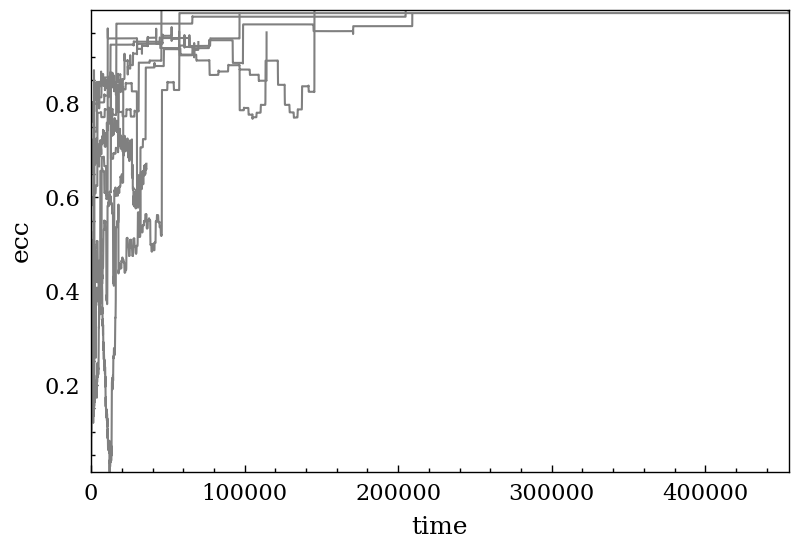

In [69]:
fig = plt.figure(figsize=(9,6))

high_peri_eccs = []
eccs = np.array(all_particles_gas[1])

for i, (peri, ecc) in enumerate(zip(all_particles_gas[0], eccs)):
    masked_ecc = np.ma.filled(eccs, np.nan)
    valid_mask = (ecc < 1)
    ecc[~valid_mask] = np.nan
        #    # ecc = np.ma.filled(ecc, np.nan)
        #     inc =test_particles[:, :, 6]
        #     inc[~valid_mask] = np.nan
        #     #ecc[~valid_mask] = np.nan

    if peri[0] > 15:
        high_peri_eccs.append(ecc)


times = np.arange(0, 1e6, 10)

for pp in high_peri_eccs[:10]:
    plt.plot(times, pp[0], c='grey')
    plt.xlabel('time')
    plt.ylabel('ecc')
plt.show()

In [53]:
fig = plt.figure(figsize=(9,6))
plt.scatter(np.array(all_particles_gas[2])/1e6, all_particles_gas[0], c='purple', s=4, label='GD')
plt.scatter(np.array(all_particles_no_gas[2])/1e6, all_particles_no_gas[0], c='steelblue', s=4, label='No GD')

plt.xlim(0.1, 1.01)
plt.xlabel('Final saved time [Myr]')
plt.ylabel('Min periastron [AU]')
plt.legend(loc='center left',        # align vertically centered to axes
        bbox_to_anchor=(1.02, 0.5),  # x=1.02 → just outside, y=0.5 → center vertically
        borderaxespad=0,          # padding between axes and legend
        frameon=False,
        fontsize=16  )
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (1955,) + inhomogeneous part.

<Figure size 900x600 with 0 Axes>

# Study of gas drag effects
Week 48 -> Meeting notes:

- take a step back! Animation doesn’t tell us much yet because we don’t know the effects of the gas drag. Build an intuition for what particles do when e.g. you give them eccentricity, or inclination. What do the planets do to the particles? Decompose gas drag effects.  One particle is enough - if there are no planets, there’s no chaos, and one particle should tell us everything.
- does gas drag naturally make exocomets?
- is the simulation sensitive to decreasing/increasing the max timestep we allow rebound to take?
- plot ellipse of particle instead of just xy position - see how fast it changes

In [ ]:
files = glob.glob('core_outputs_yr2/decomposing_GD/*a_**5myr.nc')
files = sorted(files, key=lambda f: int(re.search(r'a_(\d+)_', f).group(1)))

print(len(files), files)

In [ ]:
from cycler import cycler

def plot(toplot):
        fig, ax = plt.subplots(3,3, figsize=(12,6), sharey=False, sharex=True)
        #plt.rcParams.update({'axes.grid': False})


        colors = cmr.take_cmap_colors('cmr.dusk', 2, cmap_range=(0, 1), return_fmt='hex')
        plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
        print(colors)

        for index, file in enumerate(files[:]):
                with netCDF4.Dataset(file, 'r') as ncfile:
                        test_particles = ncfile['test_particles'][:]
                        times = test_particles[:, :2, 0]
                        ecc = test_particles[:,:2, 7]
                        a = test_particles[:, :2, 8]
                        inc = np.degrees(test_particles[:, 2:, 9])
                        vs = test_particles[:, :, 4:7]
                        v_mag = np.linalg.norm(vs, axis=2)
                        Rs = test_particles[:, :, 1:4]
                        R_mag = np.linalg.norm(Rs, axis=2)


                        ax = ax.ravel() 
                        #ax[index].set_ylim(0, 1)

                        for i in range(inc.shape[1]):

                                if toplot == 'inc':
                                        ax[index].plot(times[:,i], inc[:,i], markersize=1,)
                                if toplot == 'ecc':
                                        ax[index].plot(times[:,i], ecc[:,i], markersize=1,)
                                        ax[index].set_ylim(0, 1)

                                # ax[index].text(
                                # x=1010, #times[-1,i],  # x, y in axes fraction coordinates
                                # y = inc[-1, i],# ecc[-1, i],
                                # s = f'e = {ecc[-1, i]:.1f}',# f'{ecc[0,i]:.2f}',  # text to display
                                # #transform=ax[inSdex].transAxes,  # coordinates relative to axes
                                # # ha='right', va='top',           # align right-top
                                # fontsize=10,
                                # # color='k'
                                # )

                        plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

                        ax[index].set_title(f'{Rs[0][1]} AU', )
                        ax[index].grid()
                        if index == 0 or index==2:
                                ax[index].set_ylabel(f'{toplot}')
                        if index == 2 or index==3:
                                ax[index].set_xlabel('Time [yr]')

        plt.suptitle(f'Simulation run for {round(times[-1,-1],0)} years')
        plt.tight_layout()
        plt.show()

plot('inc'), plot('ecc')

In [ ]:
def plot_orbit_from_nc(filename):
    # Load netCDF data
    ds = netCDF4.Dataset(filename)
    data = ds['test_particles'][:]   # shape (ntimes, nparticles, nparams)
    
    x = data[:, :, 1]
    y = data[:, :, 2]
    z = data[:, :, 3]

    # For orbital evolution over time:
    e = data[:, :, 7]
    a = data[:, :, 8]

    # Plot x-y trajectory
    fig = plt.figure(figsize=(8, 8))
    #ax = fig.add_subplot(111,)

    cs = cmr.take_cmap_colors('cmr.dusk', x.shape[1], cmap_range=(0, 1), return_fmt='hex')
    print(cs)
    for particle in range(x.shape[1]):
        plt.scatter(x[:, particle], y[:,particle], marker='.', s=2, color=cs[particle],)
        

    #plt.scatter(x[0:20,0], y[0:20,0], color='red', label='initial orbit')
    #plt.scatter(x[-20:-1,0], y[-20:-1,0], color='blue', label='final orbit')
    plt.xlabel("x [AU]")
    plt.ylabel("y [AU]")
    plt.title(f"Orbital evolution of particles")
    plt.legend()
    plt.axis('equal')
    plt.grid(True)

    plt.show()

    # # Also plot a(t) and e(t)
    # plt.figure(figsize=(10,4))
    # plt.plot(a, label='a(t)')
    # # plt.plot(e, label='e(t)', color='blue')
    # plt.xlabel("Saved timestep")
    # plt.ylabel("Orbital elements")
    # plt.title(f"Evolution of a and e for particle ")
    # plt.legend()
    # plt.grid(True)
    # plt.show()

plot_orbit_from_nc(files[0])


# Animation

In [ ]:
import astropy.constants as const
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt 
import rebound 
from matplotlib.animation import FuncAnimation
import reboundx
from matplotlib.patches import Circle
from plotting_params import use_my_style
use_my_style()


In [ ]:
jtos = const.M_jup / const.M_sun

sim = rebound.Simulation()
sim.units = ['msun', 'yr', 'AU']

a_val = 0.5
R_gas = a_val+1
sim.add(m = 0.965, hash='star')
sim.add(a=a_val, e=0.5, inc=np.radians(0))
sim.N_active = 1

sim.move_to_com()

rebx = reboundx.Extras(sim)
myforce = rebx.load_force("test_force")     
rebx.add_force(myforce)

#data to save:
tmax = 40
times = np.linspace(0, tmax, int(tmax*400))

x_traj, y_traj = np.zeros_like(times), np.zeros_like(times)
e_hist = np.zeros_like(times)
v_mag = np.zeros_like(times)
i_hist = np.zeros_like(times)
a_hist = np.zeros_like(times)


#integrate
for t, tid in enumerate(times):

      if t == 0:
            p = sim.particles[1]
            e_hist[t] = p.e
            a_hist[t] = p.a
            i_hist[t] = p.inc
            x_traj[t] = p.x
            y_traj[t] = p.y

      if t > 0:
            dt = times[t] - times[t-1]
            sim.integrate(sim.t + dt)
            p = sim.particles[1]

            e_hist[t] = p.e
            a_hist[t] = p.a
            i_hist[t] = p.inc
            x_traj[t] = p.x
            y_traj[t] = p.y

            if np.cross([p.x, p.y, p.z], [p.vx, p.vy, p.vz])[2] < 0:
                  print('wrong direction!')
                  break


In [ ]:
print(np.degrees(i_hist), e_hist, a_hist)

In [ ]:
jtos = const.M_jup / const.M_sun

sim2 = rebound.Simulation()
sim2.units = ['msun', 'yr', 'AU']

tmax = 40
times = np.linspace(0, tmax, int(tmax*400))

a_val = 3

sim2.add(m = 0.965, hash='star')
sim2.add(a=a_val, e=0.5, inc=np.radians(0), f=0, omega=0, Omega=0)
sim2.add(a=a_val, e=0, inc=np.radians(0), f=0, omega=0, Omega=0)
sim2.N_active = 1

sim2.move_to_com()

x_traj2, y_traj2 = np.zeros((len(times), 2)), np.zeros((len(times), 2))
e_hist2 = np.zeros((len(times), 2))
i_hist2 = np.zeros((len(times), 2))
a_hist2 = np.zeros((len(times), 2))
v_hist2 = np.zeros((len(times), 2))
tinfo = np.zeros_like(times)

#integrate
for t, tid in enumerate(times):

      if t == 0:
            for i in range(2):
                  tinfo[t] = sim.t
                  p = sim2.particles[i+1]
                  e_hist2[t, i] = p.e
                  a_hist2[t, i] = p.a
                  i_hist2[t, i] = p.inc
                  x_traj2[t, i] = p.x
                  y_traj2[t, i] = p.y
                  v_hist2[t, i] = np.sqrt(p.vx**2 + p.vy**2 + p.vz**2)
      if t > 0:                   
            dt = times[t] - times[t-1]
            sim2.integrate(sim2.t + dt)
            for i in range(2):
                  tinfo[t] = sim.t
                  p = sim2.particles[i+1]
                  e_hist2[t, i] = p.e
                  a_hist2[t, i] = p.a
                  i_hist2[t, i] = p.inc
                  x_traj2[t, i] = p.x
                  y_traj2[t, i] = p.y
                  v_hist2[t, i] = np.sqrt(p.vx**2 + p.vy**2 + p.vz**2)*(u.au / u.yr).to(u.km / u.s)

            if np.cross([p.x, p.y, p.z], [p.vx, p.vy, p.vz])[2] < 0:
                  print('wrong direction!')
                  break

In [ ]:

# After integration is complete:

frame_idx = np.arange(0, len(times), 160)
n_frames = len(frame_idx)

print(n_frames)

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))

ax.set_xlim(0, tmax)
ax.set_ylim(9, 30)
ax.set_xlabel('Time (yr)')
ax.set_ylabel('Speed (km/s)')

c2 = "#FF931F"
c1 = "#949290"
c3 = "#FFD942"

line2, = ax.plot([], [], color=c2, lw=1, )
scat2 = ax.scatter([], [], color=c2, s=30, label='ecc = 0.5')
line1, = ax.plot([], [], color=c1, lw=1)
scat1 = ax.scatter([], [], color=c1, s=30, label='ecc = 0')


def init():
    """Initialize animation"""
    return [line1,
        line2, scat1, scat2 ]

def update(j):
    i = frame_idx[j]  # This is the time index (0, 50, 100, 150...)

    line2.set_data(times[:i+1], v_hist2[:i+1, 0])
    line1.set_data(times[:i+1], v_hist2[:i+1, 1])

    scat2.set_offsets([times[i], v_hist2[i, 0]])
    scat1.set_offsets([times[i], v_hist2[i, 1]])

    # Update title

    return [line1,
        line2, scat1, scat2,
         # line_i1,  line_e1
         ]

plt.legend(loc='upper right')
ax.set_title('Particle velocity evolution')
plt.grid(alpha=0.3)

ani = FuncAnimation(
    fig,
    update,
    init_func=init,
    frames=n_frames,
    interval=40,
    blit=True  # Now we can use blitting!
)

ani.save("gas_drag_vs_ptcl.gif", fps=10, dpi=200, writer='ffmpeg')
plt.close()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].set_xlim(-1, 1)
ax[0].set_ylim(-1, 1)
ax[0].set_xlabel('x (AU)')
ax[0].set_ylabel('y (AU)')

ax[1].set_xlim(0, tmax)
ax[1].set_ylim(0.475, 0.525)
ax[1].set_xlabel('Time (yr)')
ax[1].set_ylabel('Eccentricity')
ax[1].grid(alpha=0.4)

ax[2].set_xlim(0, tmax)
ax[2].set_ylim(0.475, 0.525)
ax[2].set_xlabel('Time (yr)')
ax[2].set_ylabel('Semimajor axis [AU]')
ax[2].grid(alpha=0.4)

# Initialize plot objects ONCE
c1 = '#661414'
c2 = "#ED852F"
c3 = "#FFD942"
# line1, = ax[0].plot([], [], color=c1, lw=1)
# scat1 = ax[0].scatter([], [], color=c1, s=30)
line2, = ax[0].plot([], [], color=c2, lw=1)
scat2 = ax[0].scatter([], [], color=c2, s=30)
star = ax[0].scatter(0, 0, color='gold', s=150)
title = ax[0].set_title('')

#line_e1, = ax[1].plot([], [], color=c1)
line_e2, = ax[1].plot([], [], color=c2)

#line_i1, = ax[2].plot([], [], color=c1)
line_i2, = ax[2].plot([], [], color=c2)

plt.tight_layout()

def init():
    """Initialize animation"""
    return [#line1, scat1,
        line2, scat2, title, 
        #line_e1,
        line_e2,
        #line_i1,
        line_i2]

def update(j):
    i = frame_idx[j]  # This is the time index (0, 50, 100, 150...)

        # Show the trail from start up to current position
    #line1.set_data(x_traj[:i+1], y_traj[:i+1])
    line2.set_data(x_traj2[:i+1], y_traj2[:i+1])

    # Current position at frame i
    #scat1.set_offsets([[x_traj[i], y_traj[i]]])
    scat2.set_offsets([[x_traj2[i], y_traj2[i]]])
    
    # Update title
    title.set_text(f"Time = {times[i]:.1f} yr")
    
    # Update eccentricity plot - ALL points up to i
    #line_e1.set_data(times[:i+1], e_hist[:i+1])
    line_e2.set_data(times[:i+1], e_hist2[:i+1])
    
    # Update inclination plot - ALL points up to i
    #line_i1.set_data(times[:i+1], a_hist[:i+1])
    line_i2.set_data(times[:i+1], a_hist2[:i+1])
    
    return [#line1, scat1,
        line2, scat2, title,line_e2, line_i2,
         # line_i1,  line_e1
         ]

ani = FuncAnimation(
    fig,
    update,
    init_func=init,
    frames=n_frames,
    interval=40,
    blit=True  # Now we can use blitting!
)

ani.save("gas_drag_example.gif", fps=10, dpi=200, writer='pillow')
plt.close()

In [ ]:
v_keplerian = np.sqrt(const.G * (0.965 * const.M_sun) / (3 * const.au)).to(u.km / u.s)
print(f'Keplerian velocity at 1 au: {v_keplerian:.2f} km/s')